# 19.0 — Synthetic Support Augmentation Experiment

## Purpose

This notebook drives the synthetic-augmentation experiment grid that backs the three thesis research questions:

- **RQ1.** Can synthetic augmentation improve few-shot department adaptation when real gold support labels are scarce, **without contaminating evaluation**?
- **RQ2.** How little real labeled data do we need before the model becomes useful enough to support decisions?
- **RQ3.** Can synthetic support augmentation reduce the support-size bottleneck in department-specific few-shot adaptation?

## Scope of this notebook

The notebook is the **runner**: it materializes the experiment grid, samples episodes with `sample_episode_with_synthetic_support`, computes realism diagnostics, dispatches a per-episode adaptation step, and writes a long-form per-episode results CSV using the canonical `EPISODIC_RESULT_ROW_SCHEMA` from `master_thesis.stage2`.

The figures and the Table 1 summary are produced by `master_thesis.synthetic_plots`, called from a small block at the end of this notebook.

## Hard invariants this notebook enforces

1. **No synthetic row in any query set.** Asserted per episode by `sample_episode_with_synthetic_support` *and* re-asserted here for safety.
2. **Per-episode reproducibility.** Each cell uses `random_state = base_seed + episode_idx`; identical inputs ⇒ identical synthetic support.
3. **Schema-conformant output.** Every result row contains exactly the columns in `EPISODIC_RESULT_ROW_SCHEMA`.

## 1. Imports and project setup

In [22]:
import os
os.environ.setdefault("OMP_NUM_THREADS", "1")
os.environ.setdefault("KMP_DUPLICATE_LIB_OK", "TRUE")

'TRUE'

In [23]:
import sys
from pathlib import Path

project_root = Path.cwd().parent
src_path = project_root / "src"
if str(src_path) not in sys.path:
    sys.path.insert(0, str(src_path))

print("project_root:", project_root)
print("src_path:    ", src_path)

project_root: /Users/annita/Desktop/Thesis/Signal_Fusion_with_Meta-learners-
src_path:     /Users/annita/Desktop/Thesis/Signal_Fusion_with_Meta-learners-/src


In [24]:
import copy
import time
import warnings
from datetime import datetime

import numpy as np
import pandas as pd
import torch
import yaml

from master_thesis.config import DATA_PROCESSED, MODELS_STAGE2, REPORTS, SEED
from master_thesis.episode_sampler import (
    build_department_task_table,
    filter_valid_departments,
    sample_episode_with_synthetic_support,
)
from master_thesis.metrics import evaluate_on_gold_binary
from master_thesis.mlp import set_seed
from master_thesis.stage2 import (
    DEFAULT_SYNTHETIC_CONFIG,
    EPISODIC_RESULT_ROW_SCHEMA,
    build_experiment_preview_df,
    build_stage2_model_from_config,
    load_stage1_model_weights,
    load_stage1_preprocessor,
    load_stage2_config,
    load_stage2_dataframe,
    resolve_experiment_grid,
    resolve_stage2_paths,
    get_feature_cols,
)
from master_thesis.synthetic_diagnostics import compute_realism_diagnostics

warnings.filterwarnings("ignore", category=RuntimeWarning)
set_seed(SEED)
device = torch.device("cuda" if torch.cuda.is_available() else "cpu")
print("device:", device)
print("EPISODIC_RESULT_ROW_SCHEMA has", len(EPISODIC_RESULT_ROW_SCHEMA), "columns.")

device: cpu
EPISODIC_RESULT_ROW_SCHEMA has 30 columns.


## 2. Load configuration and resolve the experiment grid

Pick a preset name from `experiments/stage2_config.yaml` (the synthetic-augmentation presets are prefixed `synthetic_`). The runner pulls only experiments whose resolved `synthetic_config` is well-formed and skips legacy cells silently.

In [25]:
# EDIT ME: pick the preset to run
PRESET_NAME = "synthetic_quick_debug"   # try synthetic_main_logistics for the full RQ1 sweep
CONFIG_PATH = project_root / "experiments" / "stage2_config.yaml"

full_config = load_stage2_config(CONFIG_PATH)
experiment_list = resolve_experiment_grid(full_config, preset_name=PRESET_NAME)
preview_df = build_experiment_preview_df(experiment_list)
print(f"Preset '{PRESET_NAME}' resolves to {len(experiment_list)} experiment cells.")
preview_df

Preset 'synthetic_quick_debug' resolves to 4 experiment cells.


,experiment_id,method,n_support_pos,n_support_neg,inner_steps,init_name,target_department,data_filename,synthetic_proportion,augmentation_method,target_per_class,k_neighbors
0,stage2__init-A_weak_only__method-zero_shot__kp...,zero_shot,2,2,3,A_weak_only,Logistics,contract_with_features_labeled_with_gold.csv,0.0,none,None,5
1,stage2__init-A_weak_only__method-zero_shot__kp...,zero_shot,2,2,3,A_weak_only,Logistics,contract_with_features_labeled_with_gold.csv,0.5,smote_nc,None,5
2,stage2__init-A_weak_only__method-finetune__kpo...,finetune,2,2,3,A_weak_only,Logistics,contract_with_features_labeled_with_gold.csv,0.0,none,None,5
3,stage2__init-A_weak_only__method-finetune__kpo...,finetune,2,2,3,A_weak_only,Logistics,contract_with_features_labeled_with_gold.csv,0.5,smote_nc,None,5


## 3. Load the Stage 2 dataset, the Stage 1 backbone, and the preprocessor

All cells in the grid share the same data + backbone — only the support sampling and (optionally) the inner-loop adaptation differ. We load these assets once and pass them in to the per-cell runner.

In [26]:
_, head_cfg = experiment_list[0]
head_paths = resolve_stage2_paths(head_cfg, experiment_id=experiment_list[0][0])
df_full = load_stage2_dataframe(head_paths.task_table_path)
preprocessor = load_stage1_preprocessor(head_paths.stage1_preprocessor_path)
feature_cols = get_feature_cols(head_cfg, preprocessor=preprocessor)

# Build the contract-aware department task table once.
task_df = build_department_task_table(
    features_df=df_full,
    feature_cols=feature_cols,
    contract_id_col=head_cfg["data"]["group_col"],
    department_col=head_cfg["data"]["department_col"],
    target_col=head_cfg["data"]["target_col"],
    observation_year_col=head_cfg["data"]["observation_year_col"],
    drop_missing_features=False,
)
print(f"task_df: {task_df.shape}, contracts: {task_df[head_cfg['data']['group_col']].nunique()}")
print(f"feature_cols: {len(feature_cols)}")

Stage 2 task table created
Rows: 134
Unique contracts: 21
Departments: 4
Positive labels: 101
Negative labels: 33
task_df: (134, 151), contracts: 21
feature_cols: 149


In [27]:
# Build the Stage 1 backbone once. Each per-episode adaptation will start from
# a deepcopy so the original weights remain unchanged across cells.
_dummy = preprocessor.transform(task_df[feature_cols].iloc[:2])
if hasattr(_dummy, "toarray"):
    _dummy = _dummy.toarray()
input_dim = _dummy.shape[1]

base_model = build_stage2_model_from_config(input_dim, head_cfg, device)
base_model = load_stage1_model_weights(base_model, head_paths.stage1_model_path, device)
print("Backbone loaded:", type(base_model).__name__, "input_dim=", input_dim)

Backbone loaded: TabularMLP input_dim= 889


## 4. Per-episode runner

For each `(experiment_id, config)` cell we run `n_repeats` episodes drawn with `random_state = base_seed + episode_idx`. Each episode is built by `sample_episode_with_synthetic_support`, which:

1. samples the **real** support/query split with the existing contract-aware sampler,
2. (only if `augmentation_method != "none"`) generates synthetic rows from the real support via SMOTE-NC with the **same-contract neighbor exclusion** (Option B),
3. concatenates real + synthetic support,
4. asserts that no synthetic row appears in the query.

We then run a small per-episode adapter:
- **`zero_shot`** — predict directly with the Stage 1 backbone, no inner steps.
- **`finetune`** — `inner_steps` Adam updates on the augmented support; evaluate on the real-only query.

The ANIL / FOMAML / MAML branches are intentionally deferred to a follow-up notebook; the long-form CSV records `method` for them so they can be slotted in later without breaking the schema.

In [28]:
def _resolve_categorical_cols(syn_cfg, feature_cols, df):
    """Resolve the categorical column list for SMOTE-NC.

    If the user pinned `categorical_cols` in `synthetic_config` we honour it;
    otherwise we fall back to dtype inspection on the task table.

    Auto-detect rule: any column whose pandas dtype is **not** numeric is
    treated as categorical.  This is robust to ``object``, ``string``,
    ``category``, and ``bool`` (the prior check missed pandas StringDtype
    and let string-typed columns fall into the numeric path, which crashed
    on ``.median()`` downstream).
    """
    if syn_cfg.get("categorical_cols") is not None:
        return list(syn_cfg["categorical_cols"])
    cat_cols = [
        c for c in feature_cols
        if c in df.columns and not pd.api.types.is_numeric_dtype(df[c])
    ]
    return cat_cols


def _adapt_and_predict(
    method, base_model, preprocessor, episode, feature_cols,
    target_col, inner_lr, inner_steps, device,
):
    """Apply per-episode adaptation and return query-side probabilities.

    Returns ``(y_query, probs)`` numpy arrays of equal length.
    """
    sup_df = episode["support_df"]
    qry_df = episode["query_df"]

    X_sup = preprocessor.transform(sup_df[feature_cols])
    X_qry = preprocessor.transform(qry_df[feature_cols])
    if hasattr(X_sup, "toarray"):
        X_sup = X_sup.toarray()
    if hasattr(X_qry, "toarray"):
        X_qry = X_qry.toarray()

    y_sup = torch.tensor(sup_df[target_col].to_numpy(), dtype=torch.float32, device=device).view(-1, 1)
    y_qry = qry_df[target_col].to_numpy()
    Xs = torch.tensor(X_sup, dtype=torch.float32, device=device)
    Xq = torch.tensor(X_qry, dtype=torch.float32, device=device)

    if method == "zero_shot":
        base_model.eval()
        with torch.no_grad():
            probs = torch.sigmoid(base_model(Xq)).cpu().numpy().ravel()
        return y_qry, probs

    if method == "finetune":
        adapted = copy.deepcopy(base_model)
        adapted.train()
        optim = torch.optim.Adam(adapted.parameters(), lr=inner_lr)
        crit = torch.nn.BCEWithLogitsLoss()
        for _ in range(inner_steps):
            optim.zero_grad()
            loss = crit(adapted(Xs), y_sup)
            loss.backward()
            optim.step()
        adapted.eval()
        with torch.no_grad():
            probs = torch.sigmoid(adapted(Xq)).cpu().numpy().ravel()
        return y_qry, probs

    # Methods we have not yet wired up in this notebook.  We log a row with NaN
    # metrics rather than crash, so the long-form CSV still has a coordinate
    # for them and downstream code can fill them in later.
    raise NotImplementedError(
        f"Method '{method}' is not yet wired into the synthetic-augmentation runner. "
        "Use 'zero_shot' or 'finetune' for now; ANIL/FOMAML/MAML are coming next."
    )


def _row_template():
    """Return a result-row dict with NaN/None for every column."""
    return {col: np.nan for col in EPISODIC_RESULT_ROW_SCHEMA}


print("helpers ready.")

helpers ready.


In [29]:
def run_one_cell(experiment_id, config, task_df, feature_cols, base_model,
                 preprocessor, device):
    """Run all episodes for a single experiment cell. Returns a list of dicts."""
    rows = []
    target_col = config["data"]["target_col"]
    department_col = config["data"]["department_col"]
    contract_id_col = config["data"]["group_col"]
    target_dept = config["task_config"]["target_department"]
    n_pos = int(config["support_config"]["n_support_pos"])
    n_neg = int(config["support_config"]["n_support_neg"])
    inner_steps = int(config["meta_config"]["inner_steps"])
    inner_lr = float(config["meta_config"]["inner_lr"])
    n_repeats = int(config["meta_config"].get("n_repeats", 5))
    base_seed = int(config.get("seed", SEED))
    method = config["method"].lower()
    init_name = config["stage1_init"]["init_name"]

    syn_cfg = config.get("synthetic_config") or DEFAULT_SYNTHETIC_CONFIG
    aug_method = syn_cfg.get("augmentation_method", "none")
    syn_prop = float(syn_cfg.get("synthetic_proportion", 0.0))
    target_per_class = syn_cfg.get("target_per_class")
    k_neighbors = int(syn_cfg.get("k_neighbors", DEFAULT_SYNTHETIC_CONFIG["k_neighbors"]))
    seed_offset = int(syn_cfg.get("augmentation_seed_offset",
                                  DEFAULT_SYNTHETIC_CONFIG["augmentation_seed_offset"]))

    dept_df = task_df[task_df[department_col] == target_dept].copy()
    if len(dept_df) == 0:
        return rows  # nothing to do for this department

    cat_cols = _resolve_categorical_cols(syn_cfg, feature_cols, dept_df)
    num_cols = [c for c in feature_cols if c not in cat_cols]

    for ep_idx in range(n_repeats):
        ep_seed = base_seed + ep_idx
        try:
            episode = sample_episode_with_synthetic_support(
                dept_df=dept_df,
                feature_cols=feature_cols,
                department_name=target_dept,
                target_col=target_col,
                department_col=department_col,
                contract_id_col=contract_id_col,
                n_support_pos=n_pos,
                n_support_neg=n_neg,
                augmentation_method=aug_method,
                synthetic_proportion=(syn_prop if aug_method != "none" else None),
                target_per_class=target_per_class,
                categorical_cols=cat_cols,
                k_neighbors=k_neighbors,
                augmentation_seed_offset=seed_offset,
                random_state=ep_seed,
            )
        except (ValueError, RuntimeError) as e:
            row = _row_template()
            row.update({
                "experiment_id": experiment_id, "department": target_dept,
                "init_name": init_name, "method": method,
                "real_k": min(n_pos, n_neg), "n_support_pos": n_pos, "n_support_neg": n_neg,
                "syn_prop": syn_prop, "gen_method": aug_method,
                "target_per_class": target_per_class,
                "seed": ep_seed, "episode_idx": ep_idx,
                "gen_fallback_used": True,
            })
            rows.append(row)
            continue

        # Hard leakage guard: re-assert here on top of the assertion inside
        # sample_episode_with_synthetic_support.
        qry_ids = episode["query_df"][contract_id_col].astype(str).tolist()
        synth_in_query = [q for q in qry_ids if q.startswith("SYNTH_")]
        assert not synth_in_query, (
            f"Synthetic IDs leaked into query for cell {experiment_id} / ep {ep_idx}"
        )

        info = episode["augmentation_info"]
        n_real = int(info["n_real_support_rows"])
        n_syn = int(info["n_synthetic_support_rows"])
        gen_fallback = bool(info.get("fallback_used", False))

        # Realism diagnostics — only meaningful when we actually generated rows.
        if n_syn > 0:
            real_sup = episode["support_df"][~episode["is_synthetic_mask"]].copy()
            synth_sup = episode["support_df"][episode["is_synthetic_mask"]].copy()
            diag = compute_realism_diagnostics(
                real_support_df=real_sup,
                synth_support_df=synth_sup,
                num_cols=num_cols,
                cat_cols=cat_cols,
            )
        else:
            diag = {
                "dist_to_nearest_real_mean": np.nan,
                "dist_to_nearest_real_p95": np.nan,
                "ks_max": np.nan, "ks_median": np.nan,
                "cat_mode_preservation_mean": np.nan,
                "cat_mode_preservation_min": np.nan,
            }

        # Adaptation + query-side prediction
        try:
            y_qry, probs = _adapt_and_predict(
                method=method, base_model=base_model, preprocessor=preprocessor,
                episode=episode, feature_cols=feature_cols, target_col=target_col,
                inner_lr=inner_lr, inner_steps=inner_steps, device=device,
            )
        except NotImplementedError:
            # Method not wired yet — record the cell with NaN metrics.
            row = _row_template()
            row.update({
                "experiment_id": experiment_id, "department": target_dept,
                "init_name": init_name, "method": method,
                "real_k": min(n_pos, n_neg), "n_support_pos": n_pos, "n_support_neg": n_neg,
                "syn_prop": syn_prop, "gen_method": aug_method,
                "target_per_class": target_per_class,
                "seed": ep_seed, "episode_idx": ep_idx,
                "n_real_support_rows": n_real,
                "n_real_support_contracts": int(
                    episode["support_df"].loc[~episode["is_synthetic_mask"], contract_id_col].nunique()
                ),
                "n_synthetic_support_rows": n_syn,
                "n_query_rows": int(len(episode["query_df"])),
                "gen_fallback_used": gen_fallback,
                **diag,
            })
            rows.append(row)
            continue

        # Predictive metrics
        metrics = evaluate_on_gold_binary(y_qry, probs, model_name=method.upper())
        metrics_row = metrics.iloc[0] if hasattr(metrics, "iloc") else metrics
        auroc = float(metrics_row.get("gold_auroc", np.nan))
        ap = float(metrics_row.get("gold_ap", np.nan))
        ndcg10 = float(metrics_row.get("ndcg_at_10", np.nan))
        ece = float(metrics_row.get("gold_ece", np.nan))
        pred_mean = float(np.mean(probs))
        pred_std = float(np.std(probs, ddof=0))
        # "Collapse" heuristic from prediction_stats: spread < 0.05 → degenerate.
        collapsed = bool(pred_std < 0.05)

        row = _row_template()
        row.update({
            "experiment_id": experiment_id,
            "department": target_dept,
            "init_name": init_name,
            "method": method,
            "real_k": min(n_pos, n_neg),
            "n_support_pos": n_pos,
            "n_support_neg": n_neg,
            "syn_prop": syn_prop,
            "gen_method": aug_method,
            "target_per_class": target_per_class,
            "seed": ep_seed,
            "episode_idx": ep_idx,
            "n_real_support_rows": n_real,
            "n_real_support_contracts": int(
                episode["support_df"].loc[~episode["is_synthetic_mask"], contract_id_col].nunique()
            ),
            "n_synthetic_support_rows": n_syn,
            "n_query_rows": int(len(episode["query_df"])),
            "auroc": auroc, "ap": ap, "ndcg_at_10": ndcg10, "ece": ece,
            "pred_mean": pred_mean, "pred_std": pred_std, "collapsed": collapsed,
            "gen_fallback_used": gen_fallback,
            **diag,
        })
        rows.append(row)
    return rows


print("runner ready.")

runner ready.


## 5. Outer loop over the experiment grid

For each cell we call `run_one_cell` and concatenate its rows into a single long-form DataFrame. Cells whose `method` is not yet wired (ANIL / FOMAML / MAML) are recorded with NaN metrics so the schema stays uniform.

In [30]:
all_rows = []
skipped = []
t0 = time.time()
for i, (exp_id, cfg) in enumerate(experiment_list, start=1):
    method = cfg["method"].lower()
    if method not in ("zero_shot", "finetune"):
        skipped.append((exp_id, method))
        continue
    cell_rows = run_one_cell(
        experiment_id=exp_id, config=cfg,
        task_df=task_df, feature_cols=feature_cols,
        base_model=base_model, preprocessor=preprocessor, device=device,
    )
    all_rows.extend(cell_rows)
    elapsed = time.time() - t0
    print(f"[{i:>3}/{len(experiment_list)}] {exp_id}  -> {len(cell_rows)} rows  (elapsed={elapsed:.1f}s)")

results_df = pd.DataFrame(all_rows, columns=list(EPISODIC_RESULT_ROW_SCHEMA))
print()
print(f"Collected {len(results_df)} per-episode rows across {results_df['experiment_id'].nunique()} cells.")
if skipped:
    print(f"Skipped {len(skipped)} cells (method not yet wired):")
    for eid, m in skipped[:5]:
        print(f"  - {eid}  ({m})")
    if len(skipped) > 5:
        print(f"  ... and {len(skipped) - 5} more.")

[  1/4] stage2__init-A_weak_only__method-zero_shot__kpos-2__kneg-2__steps-3__target-Logistics__synprop-0__gen-none  -> 5 rows  (elapsed=0.4s)
[  2/4] stage2__init-A_weak_only__method-zero_shot__kpos-2__kneg-2__steps-3__target-Logistics__synprop-0.5__gen-smote_nc  -> 5 rows  (elapsed=0.9s)
[  3/4] stage2__init-A_weak_only__method-finetune__kpos-2__kneg-2__steps-3__target-Logistics__synprop-0__gen-none  -> 5 rows  (elapsed=1.0s)
[  4/4] stage2__init-A_weak_only__method-finetune__kpos-2__kneg-2__steps-3__target-Logistics__synprop-0.5__gen-smote_nc  -> 5 rows  (elapsed=1.5s)

Collected 20 per-episode rows across 4 cells.


In [31]:
if not results_df.empty:
    display(results_df.head(8))
    display(
        results_df
        .groupby(["department", "real_k", "method", "gen_method", "syn_prop"], dropna=False)
        [["auroc", "ap", "ndcg_at_10", "ece", "pred_std", "collapsed"]]
        .agg(["mean", "std", "count"])
        .round(3)
    )

,experiment_id,department,init_name,method,real_k,n_support_pos,n_support_neg,syn_prop,gen_method,target_per_class,...,pred_mean,pred_std,collapsed,gen_fallback_used,dist_to_nearest_real_mean,dist_to_nearest_real_p95,ks_max,ks_median,cat_mode_preservation_mean,cat_mode_preservation_min
0,stage2__init-A_weak_only__method-zero_shot__kp...,Logistics,A_weak_only,zero_shot,2,2,2,0.0,none,None,...,0.181954,0.144466,False,False,NaN,NaN,NaN,NaN,NaN,NaN
1,stage2__init-A_weak_only__method-zero_shot__kp...,Logistics,A_weak_only,zero_shot,2,2,2,0.0,none,None,...,0.217090,0.132621,False,False,NaN,NaN,NaN,NaN,NaN,NaN
2,stage2__init-A_weak_only__method-zero_shot__kp...,Logistics,A_weak_only,zero_shot,2,2,2,0.0,none,None,...,0.159925,0.147685,False,False,NaN,NaN,NaN,NaN,NaN,NaN
3,stage2__init-A_weak_only__method-zero_shot__kp...,Logistics,A_weak_only,zero_shot,2,2,2,0.0,none,None,...,0.234494,0.112272,False,False,NaN,NaN,NaN,NaN,NaN,NaN
4,stage2__init-A_weak_only__method-zero_shot__kp...,Logistics,A_weak_only,zero_shot,2,2,2,0.0,none,None,...,0.180700,0.131072,False,False,NaN,NaN,NaN,NaN,NaN,NaN
5,stage2__init-A_weak_only__method-zero_shot__kp...,Logistics,A_weak_only,zero_shot,2,2,2,0.5,smote_nc,None,...,0.181954,0.144466,False,False,1.429501e+07,3.485635e+07,0.666667,0.0,0.772619,0.0
6,stage2__init-A_weak_only__method-zero_shot__kp...,Logistics,A_weak_only,zero_shot,2,2,2,0.5,smote_nc,None,...,0.217090,0.132621,False,False,9.883802e+06,2.542197e+07,0.666667,0.0,0.824405,0.0
7,stage2__init-A_weak_only__method-zero_shot__kp...,Logistics,A_weak_only,zero_shot,2,2,2,0.5,smote_nc,None,...,0.159925,0.147685,False,False,4.397739e+06,9.984986e+06,0.800000,0.0,0.871071,0.0


auroc                  ap  \
                                                  mean    std count   mean   
department real_k method    gen_method syn_prop                              
Logistics  2      finetune  none       0.0       0.500  0.000     5  0.872   
                            smote_nc   0.5       0.500  0.000     5  0.872   
                  zero_shot none       0.0       0.707  0.066     5  0.956   
                            smote_nc   0.5       0.707  0.066     5  0.956   

                                                             ndcg_at_10  \
                                                   std count       mean   
department real_k method    gen_method syn_prop                           
Logistics  2      finetune  none       0.0       0.060     5      0.900   
                            smote_nc   0.5       0.060     5      0.900   
                  zero_shot none       0.0       0.027     5      0.928   
                            smote_nc   0.5       0.027     5      0.928   

                                                                ece         \
                                                   std count   mean    std   
department real_k method    gen_method syn_prop                              
Logistics  2      finetune  none       0.0       0.076     5  0.128  0.060   
                            smote_nc   0.5       0.076     5  0.128  0.060   
                  zero_shot none       0.0       0.078     5  0.677  0.082   
                            smote_nc   0.5       0.078     5  0.677  0.082   

                                                      pred_std               \
                                                count     mean    std count   
department real_k method    gen_method syn_prop                               
Logistics  2      finetune  none       0.0          5    0.000  0.000     5   
                            smote_nc   0.5          5    0.000  0.000     5   
                  zero_shot none       0.0          5    0.134  0.014     5   
                            smote_nc   0.5          5    0.134  0.014     5   

                                                collapsed             
                                                     mean  std count  
department real_k method    gen_method syn_prop                       
Logistics  2      finetune  none       0.0            1.0  0.0     5  
                            smote_nc   0.5            1.0  0.0     5  
                  zero_shot none       0.0            0.0  0.0     5  
                            smote_nc   0.5            0.0  0.0     5

## 6. Persist long-form results CSV

Saved to `models/stage_2/experiments/_synthetic_augmentation/episode_results__<timestamp>.csv`. Downstream notebooks (and `master_thesis.synthetic_plots`) consume this file.

In [32]:
out_dir = MODELS_STAGE2 / "experiments" / "_synthetic_augmentation"
out_dir.mkdir(parents=True, exist_ok=True)
stamp = datetime.utcnow().strftime("%Y%m%dT%H%M%SZ")
out_path = out_dir / f"episode_results__{PRESET_NAME}__{stamp}.csv"
results_df.to_csv(out_path, index=False)
print("Saved:", out_path)

# Also drop a small JSON breadcrumb so the plot notebook can find the latest run.
latest_path = out_dir / "latest_run.json"
with open(latest_path, "w", encoding="utf-8") as f:
    yaml.safe_dump({
        "preset": PRESET_NAME,
        "timestamp_utc": stamp,
        "results_csv": str(out_path),
        "n_rows": int(len(results_df)),
        "n_cells": int(results_df["experiment_id"].nunique()),
        "n_skipped_cells": len(skipped),
    }, f, sort_keys=False)
print("Breadcrumb:", latest_path)

Saved: /Users/annita/Desktop/Thesis/Signal_Fusion_with_Meta-learners-/models/stage_2/experiments/_synthetic_augmentation/episode_results__synthetic_quick_debug__20260425T155347Z.csv
Breadcrumb: /Users/annita/Desktop/Thesis/Signal_Fusion_with_Meta-learners-/models/stage_2/experiments/_synthetic_augmentation/latest_run.json


/var/folders/6x/p6ddm7q51q76jspdhc1_xrm80000gn/T/ipykernel_63417/3911368259.py:3: DeprecationWarning: datetime.datetime.utcnow() is deprecated and scheduled for removal in a future version. Use timezone-aware objects to represent datetimes in UTC: datetime.datetime.now(datetime.UTC).
  stamp = datetime.utcnow().strftime("%Y%m%dT%H%M%SZ")


## 7. Figures and Table 1

All figures + the Table 1 summary live in `master_thesis.synthetic_plots`. Re-run only this section to refresh the artifacts after a fresh experiment run.

Saved:
  Fig 1: Figure(800x500)
  Fig 2: Figure(400x400)
  Fig 3: Figure(1200x400)
  Table1: /Users/annita/Desktop/Thesis/Signal_Fusion_with_Meta-learners-/reports/figures/synthetic_augmentation/table1_summary__20260425T155347Z.csv


,department,init_name,method,real_k,gen_method,syn_prop,n_episodes,auroc_mean,auroc_sem,auroc_n,...,ks_median_mean,ks_median_sem,ks_median_n,cat_mode_preservation_mean_mean,cat_mode_preservation_mean_sem,cat_mode_preservation_mean_n,cat_mode_preservation_min_mean,cat_mode_preservation_min_sem,cat_mode_preservation_min_n,collapse_rate
0,Logistics,A_weak_only,finetune,2,none,0.0,5,0.500000,0.000000,5,...,NaN,NaN,0,NaN,NaN,0,NaN,NaN,0,1.0
1,Logistics,A_weak_only,finetune,2,smote_nc,0.5,5,0.500000,0.000000,5,...,0.0,0.0,5,0.859214,0.027297,5,0.0,0.0,5,1.0
2,Logistics,A_weak_only,zero_shot,2,none,0.0,5,0.706645,0.029549,5,...,NaN,NaN,0,NaN,NaN,0,NaN,NaN,0,0.0
3,Logistics,A_weak_only,zero_shot,2,smote_nc,0.5,5,0.706645,0.029549,5,...,0.0,0.0,5,0.859214,0.027297,5,0.0,0.0,5,0.0


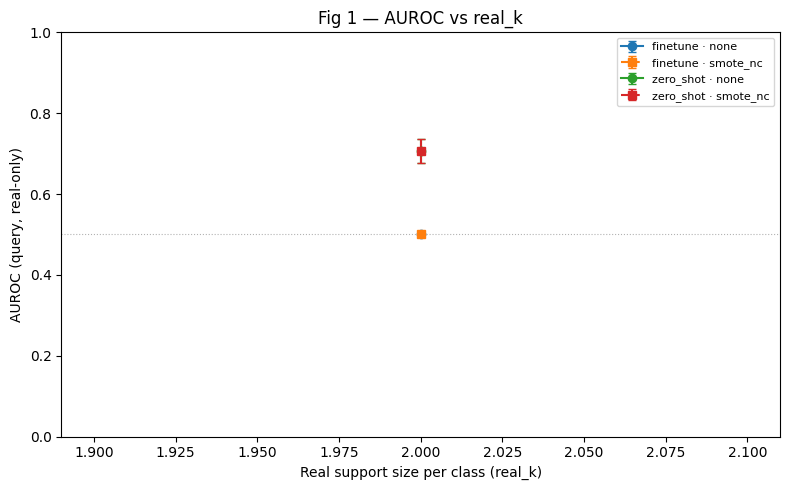

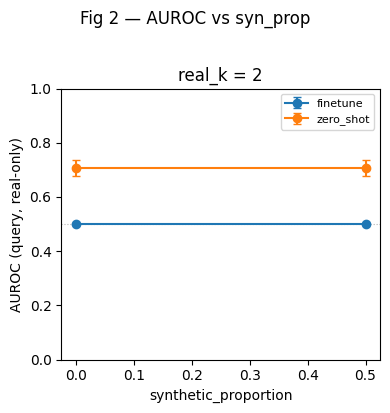

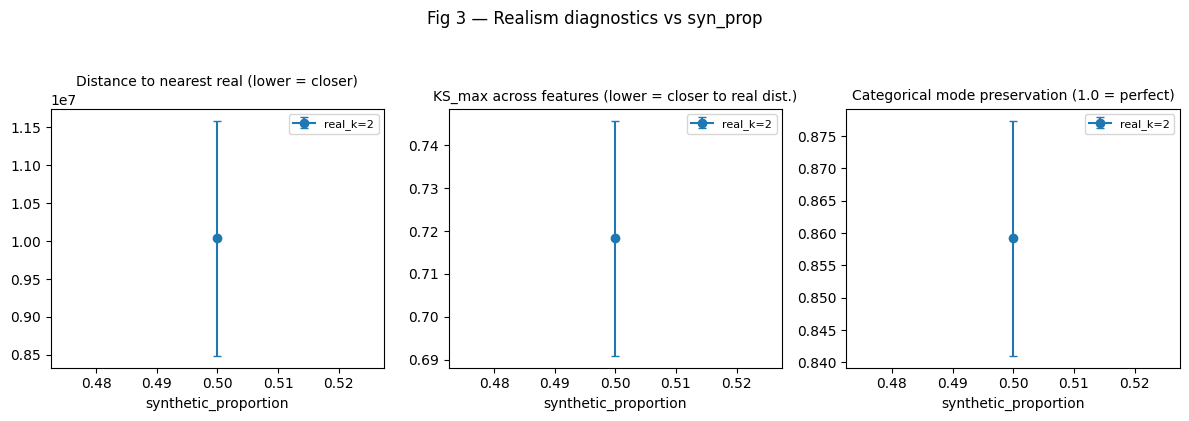

In [33]:
from master_thesis.synthetic_plots import (
    plot_auroc_vs_real_k,
    plot_auroc_vs_syn_prop,
    plot_realism_vs_syn_prop,
    build_summary_table,
)

fig_dir = REPORTS / "figures" / "synthetic_augmentation"
fig_dir.mkdir(parents=True, exist_ok=True)

if results_df.empty:
    print("No results — skip plots.")
else:
    f1 = plot_auroc_vs_real_k(results_df, save_to=fig_dir / f"fig1_auroc_vs_real_k__{stamp}.png")
    f2 = plot_auroc_vs_syn_prop(results_df, save_to=fig_dir / f"fig2_auroc_vs_syn_prop__{stamp}.png")
    f3 = plot_realism_vs_syn_prop(results_df, save_to=fig_dir / f"fig3_realism_vs_syn_prop__{stamp}.png")
    table1 = build_summary_table(results_df)
    table1_path = fig_dir / f"table1_summary__{stamp}.csv"
    table1.to_csv(table1_path, index=False)
    print("Saved:")
    print("  Fig 1:", f1)
    print("  Fig 2:", f2)
    print("  Fig 3:", f3)
    print("  Table1:", table1_path)
    display(table1)